# Import

In [1]:
%matplotlib inline

import sys
import datacube
import skimage.exposure
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import Image
from IPython.core.display import Video
import xarray as xr
import numpy as np
import os
import imageio

from matplotlib import colors as mcolours

sys.path.insert(1, "../Tools/")
from dea_tools.bandindices import calculate_indices
from dea_tools.plotting import xr_animation, rgb, display_map
from dea_tools.landcover import get_layer_name, lc_colours, lc_colourmap


# Parameter cell
Add things here that are needed to run the rest of the notebook. This way the rest of the notebook can be left alone and shouldn't need to be edited.


In [2]:
x = (142.41, 142.57)
y = (-32.225, -32.325)
time = 2015 # single year
time_range = (2015,2020) # for timeseries

comparison_out = 'collections comparison'
timeseries_out = 'interesting timeseries'

text_size =  15

# query params
bands = ['level3', 'level4']


In [3]:
# create output folders if they do not exist alreadyabs

for folder in [comparison_out,timeseries_out]:
    if not os.path.exists(folder):
        os.makedirs(folder)

# Connect to dev sandbox database

In [4]:
dc = datacube.Datacube(app="lc3_vs_lc2")

# Display variable names of LC collections

In [5]:
# display collections' variable names (i.e., measurements)

lc_2_name = "ga_ls_landcover_class_cyear_2"
lc_3_name = "ga_ls_landcover_class_cyear_3"

measurements = dc.list_measurements()

for product in [lc_2_name, lc_3_name]:
    print(f'{product}\n')
    display(measurements.loc[product])
    print('\n\n')

ga_ls_landcover_class_cyear_2



,name,dtype,units,nodata,aliases,flags_definition
measurement,,,,,,
level3,level3,uint8,1,0,NaN,NaN
lifeform_veg_cat_l4a,lifeform_veg_cat_l4a,uint8,1,0,[lifeform],NaN
canopyco_veg_cat_l4d,canopyco_veg_cat_l4d,uint8,1,0,[vegetation_cover],NaN
watersea_veg_cat_l4a_au,watersea_veg_cat_l4a_au,uint8,1,0,[water_seasonality],NaN
waterstt_wat_cat_l4a,waterstt_wat_cat_l4a,uint8,1,0,[water_state],NaN
inttidal_wat_cat_l4a,inttidal_wat_cat_l4a,uint8,1,0,[intertidal],NaN
waterper_wat_cat_l4d_au,waterper_wat_cat_l4d_au,uint8,1,0,[water_persistence],NaN
baregrad_phy_cat_l4d_au,baregrad_phy_cat_l4d_au,uint8,1,0,[bare_gradation],NaN
level4,level4,uint8,1,0,[full_classification],NaN





ga_ls_landcover_class_cyear_3



,name,dtype,units,nodata,aliases,flags_definition
measurement,,,,,,
level3,level3,uint8,1,255,NaN,NaN
level4,level4,uint8,1,255,[full_classification],NaN


# Load LC products

In [6]:
def query_(lat_range, 
            lon_range,  
            year):

    '''
    Generates dc.load() query

    year: integer, string (one year only), tuple, or list of 2 elements
    '''

    try: # if year is provide as an integer, this will fail because cannot use len(), and will go to the except
        if len(year) == 2: 
            query = {
                    "y": lat_range,
                    "x": lon_range,
                    "time": [str(y) for y in year],
                    }
        else:
            raise KeyError('`year` must be either an integer, a tuple, or a list of 2 elements')

    except: 
        query = {
                "y": lat_range,
                "x": lon_range,
                "time": str(year),
                }

    return query


In [7]:
# define query

query = query_(lat_range =y,
             lon_range =x ,
             year = time,
            )

In [8]:
# LC collection 2
lc_2 = dc.load(
    product=lc_2_name,
    output_crs="EPSG:3577",
    measurements=[
        "level3",
        "level4",
    ],
    resolution=(-25, 25),
    **query
)


# LC collection 3
lc_3 = dc.load(
    product=lc_3_name,
    output_crs="EPSG:3577",
    measurements=[
        "level3",
        "level4",
    ],
    resolution=(-25, 25),
    **query
)

# Create single images and gif for comparing collection 2 and 3

## Modified DEA tools functions 

In [9]:
def lc_colourmap_modified(colour_scheme, colour_bar=False ): 
    """
    Returns colour map and normalisation for the provided DEA Land Cover
    measurement, for use in plotting with Matplotlib library
    
    Parameters
    ----------
    colour_scheme : string
        Name of land cover colour scheme to use
        Valid options: 'level3', 'level4', 'lifeform_veg_cat_l4a', 
        'canopyco_veg_cat_l4d', 'watersea_veg_cat_l4a_au',
        'waterstt_wat_cat_l4a', 'inttidal_wat_cat_l4a', 
        'waterper_wat_cat_l4d_au', 'baregrad_phy_cat_l4d_au'.
    colour_bar : bool, optional
        Controls if colour bar labels are returned as a list for 
        plotting a colour bar. Default: False.
        
    Returns
    ---------
    cmap : matplotlib colormap
        Matplotlib colormap containing the colour scheme for the
        specified DEA Land Cover measurement.
    norm : matplotlib colormap index
        Matplotlib colormap index based on the discrete intervals of the
        classes in the specified DEA Land Cover measurement. Ensures the
        colormap maps the colours to the class numbers correctly.
    cblables : array
        A two dimentional array containing the numerical class values
        (first dim) and string labels (second dim) of the classes found
        in the chosen DEA Land Cover measurement.
    """

    colour_scheme = colour_scheme.lower()
    # Ensure a valid colour scheme was requested
#     try:
    assert (colour_scheme in lc_colours.keys(
    )), f'colour scheme must be one of [{lc_colours.keys()}] (got "{colour_scheme}")'

#     ('The dataset provided does not have a valid '
#     'name. Please specify which DEA Landcover measurement is being plotted '
#     'by providing the name using the "measurement" variable. For example (measurement = "full_classification")')

    # Get colour definitions
    lc_colour_scheme = lc_colours[colour_scheme]

    # Create colour map
    colour_arr = []
    for key, value in lc_colour_scheme.items():
        colour_arr.append(np.array(value[:-2]) / 255)

    cmap = mcolours.ListedColormap(colour_arr)
    bounds = list(lc_colour_scheme)

    if colour_bar == True:
        if colour_scheme == 'level4':
            # Set colour labels to shortened level 4 list
            lc_colour_scheme = lc_colours['level4_colourbar_labels']
        cb_ticks = list(lc_colour_scheme) 
        cb_labels = []
        for x in cb_ticks:
            cb_labels.append(lc_colour_scheme[x][4].split(':')[0]) #### added split to simplify ####

    bounds.append(bounds[-1]+1)
    norm = mcolours.BoundaryNorm(np.array(bounds), cmap.N)

    if colour_bar == False:
        return (cmap, norm)
    else:
        return (cmap, norm, cb_labels, cb_ticks)

In [10]:
def make_colorbar_modified(fig, ax, measurement,horizontal=False, animation=False):
    """
    Adds a new colorbar with appropriate land cover colours and labels.

    For DEA Land Cover Level 4 data, this function must be used with a double plot. 
    The 'ax' should be on the left side of the figure, and the colour bar will added 
    on the right hand side.
    
    Parameters
    ----------
    fig : matplotlib figure
        Figure to add colourbar to
    ax : matplotlib ax
        Matplotlib figure ax to add colorbar to.
    measurement : str
        Land cover measurement to use for colour map and labels. 
    
    """
    # Create new axis object for colorbar
    # parameters for add_axes are [left, bottom, width, height], in
    # fractions of total plot
    
    if measurement == 'level4' and animation == True:
        
        # special spacing settings for level 4
        cax = fig.add_axes([0.62, 0.10, 0.02, 0.80])
        orient = 'vertical'
        
            # get level 4 colour bar colour map ect
        cb_cmap, cb_norm, cb_labels, cb_ticks = lc_colourmap_modified('level4_colourbar_labels',
                                                         colour_bar=True)
    elif measurement == 'level4' and animation == False:
        
        # get level 4 colour bar colour map ect
        cb_cmap, cb_norm, cb_labels, cb_ticks = lc_colourmap_modified('level4_colourbar_labels',
                                                         colour_bar=True)
        #move plot over to make room for colourbar
        fig.subplots_adjust(right=0.825)

        # Settings for axis positions
        cax = fig.add_axes([0.84, 0.15, 0.02, 0.70])
        orient = 'vertical'
        
    else:
        #for all other measurements 

        #move plot over to make room for colourbar
        fig.subplots_adjust(right=0.825)

        # Settings for different axis positions
        if horizontal:
            cax = fig.add_axes([0.02, 0.05, 0.90, 0.03])
            orient = 'horizontal'
        else:
            cax = fig.add_axes([0.84, 0.15, 0.02, 0.70])
            orient = 'vertical'
            
        # get measurement colour bar colour map ect
        cb_cmap, cb_norm, cb_labels, cb_ticks = lc_colourmap_modified(measurement,
                                                         colour_bar=True)

    img = ax.imshow([cb_ticks], cmap=cb_cmap, norm=cb_norm)
    cb = fig.colorbar(img, cax=cax, orientation=orient)

    cb.ax.tick_params(labelsize=12)
    cb.set_ticks(cb_ticks + np.diff(cb_ticks, append=cb_ticks[-1]+1) / 2)
    cb.set_ticklabels(cb_labels)

In [11]:
def plot_land_cover_modified(data, list_titles=None,year=None, measurement=None, out_width=15, cols=4,):
    """
    Plot a single land cover measurement with appropriate colour scheme.
    Parameters
    ----------
    data : xarray.DataArray
        A dataArray containing a DEA Land Cover classification.
    year : int, optional
        Can be used to select to plot a specific year. If not provided,
        all time slices are plotted.
    measurement : string, optional
        Name of the DEA land cover classification to be plotted. Passed to 
        lc_colourmap to specify which colour scheme will be used. If non 
        provided, reads data array name from `da` to determine.
    """
    # get measurement name
    measurement = get_layer_name(measurement, data)

    # get colour map, normalisation
    try:
        cmap, norm = lc_colourmap(measurement)
    except AssertionError:

        raise KeyError('Could not automatically determine colour scheme from'
                       f'DataArray name {measurement}. Please specify which '
                       'DEA Landcover measurement is being plotted by providing'
                       'the name using the "measurement" variable For example'
                       '(measurement = "full_classification")')

    height, width = data.geobox.shape
    scale = out_width / width

    if year:
        #plotting protocall if 'year' variable is passed
        year_string = f"{year}-01-01"
        data = data.sel(time=year_string, method="nearest")
        
        fig, ax = plt.subplots()
        fig.set_size_inches(width * scale, height * scale)
        make_colorbar_modified(fig, ax, measurement)

        # remove ticks
        ax.set_xticks([])
        ax.set_yticks([])

        im = ax.imshow(data, cmap=cmap, norm=norm, interpolation="nearest")

        

    
    elif len(data.time) == 1:
        #plotting protocall if only one timestep is passed and not a year variable
        fig, ax = plt.subplots()
        fig.set_size_inches(width * scale, height * scale)
        
        data = data.isel(time=0)  

        make_colorbar_modified(fig, ax, measurement)

        im = ax.imshow(data, cmap=cmap, norm=norm, interpolation="nearest")

        # remove ticks
        ax.set_xticks([])
        ax.set_yticks([])

     
    else:
        #plotting protocall if multible time steps are passed to plot
        if cols > len(data.time):
            cols = len(data.time)
        rows = int((len(data.time) + cols-1)/cols)

        fig, ax = plt.subplots(nrows=rows, ncols=cols)
        fig.set_size_inches(
            width * scale, (height * scale / cols) * (len(data.time) / cols))

        make_colorbar_modified(fig, ax.flat[0], measurement)

        for (a, b), title in zip(enumerate(ax.flat), list_titles):
            if a < data.shape[0]:
                
                im = b.imshow(data[a], cmap=cmap, norm=norm,
                              interpolation="nearest")

                b.set_title(title)
                
                # remove ticks
                b.set_xticks([])  
                b.set_yticks([]) 

        

    return im

In [12]:
def save_fig(ds, band, year, output_folder, collection_name):

    band_name_formatted = f'{band[:5].capitalize()} {band[-1]}'
    
    title = f'{collection_name}, {band_name_formatted}, {year}'

    # use DEA function to create the figure
    image = plot_land_cover_modified(ds[band], year=year,)
    
    # add title
   
    #plt.title(title,
    #          fontsize=text_size, 
     #         x=-18.0, # shift the title toward centre of map
     #        )


    plt.text(-20, 0.98, title, transform=plt.gca().transAxes,
             fontsize=30, verticalalignment='top',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    
    # save figure
    plt.savefig(f'{output_folder}/{title}.png',
               bbox_inches='tight') # avoid cropping lables of colourbar
    
    # Show the plot
    plt.show()
    

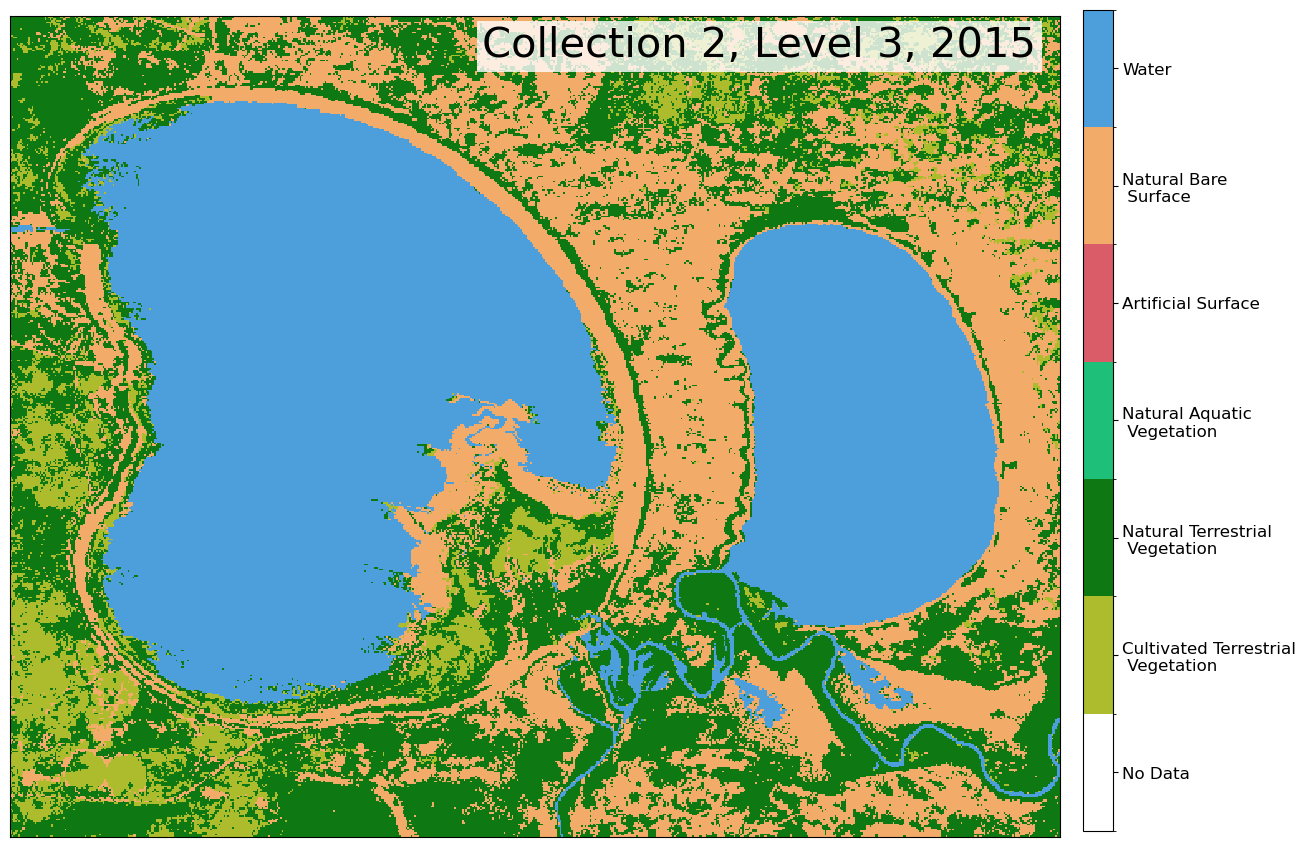

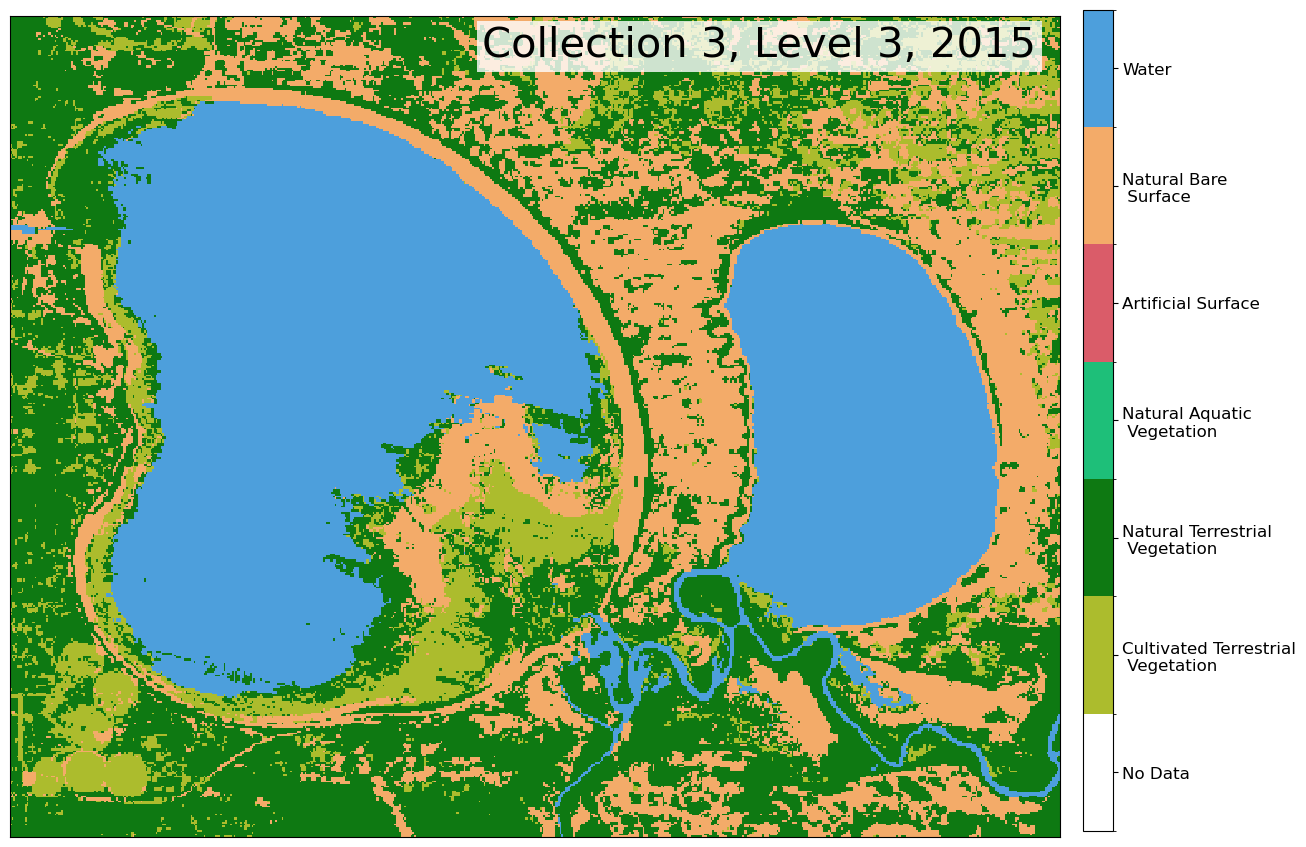

/tmp/ipykernel_153/1864024439.py:15: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(file_path)) # add file to list


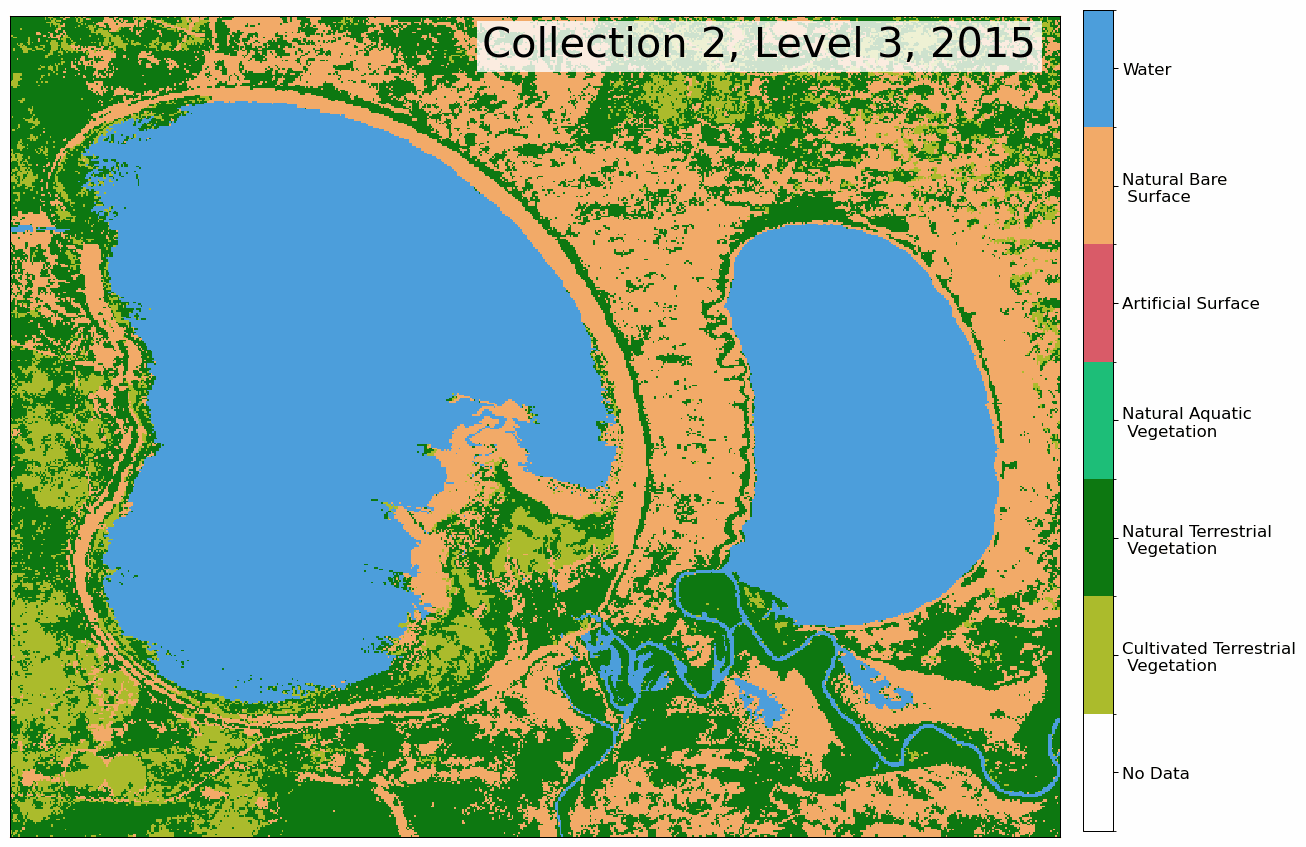

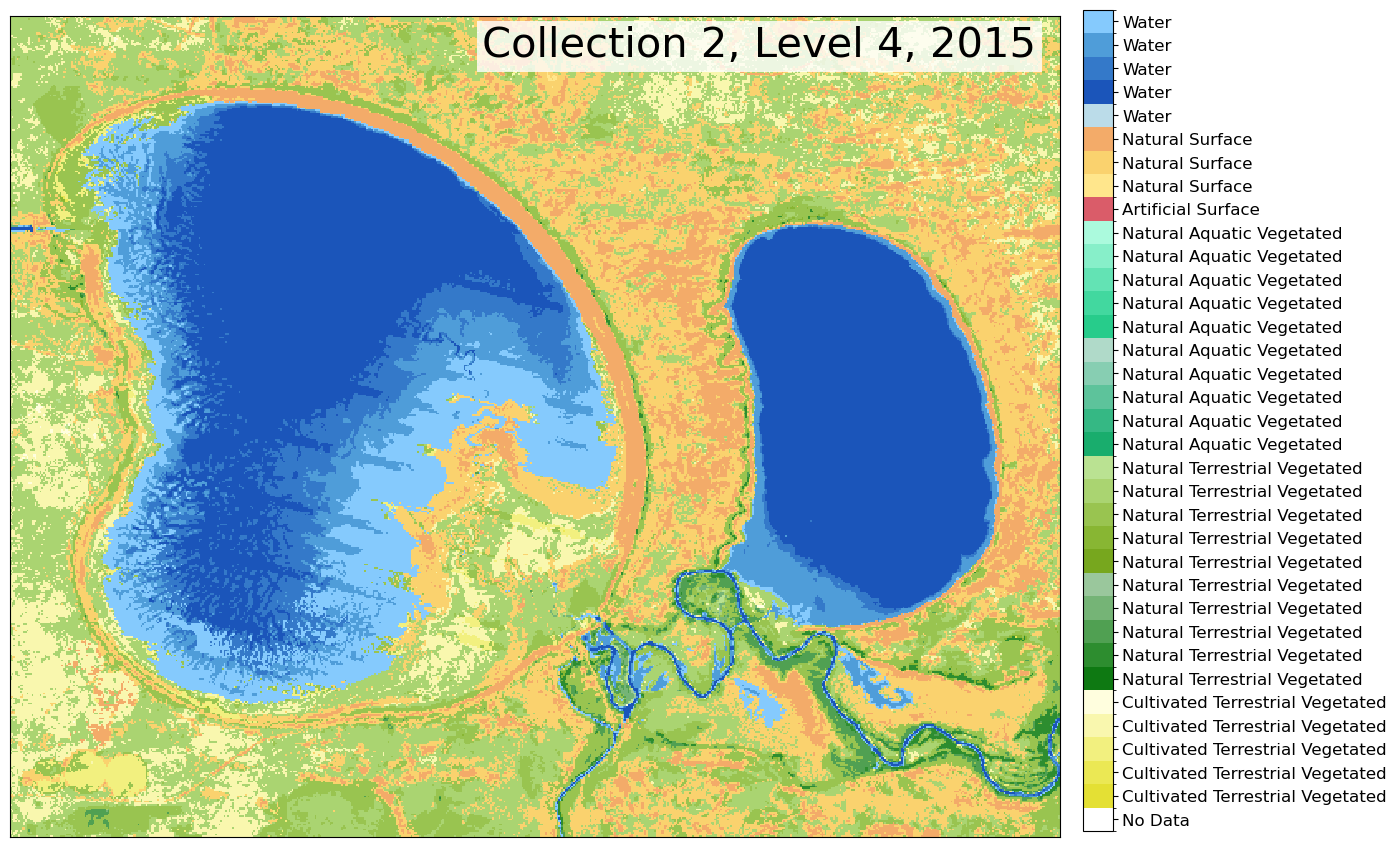

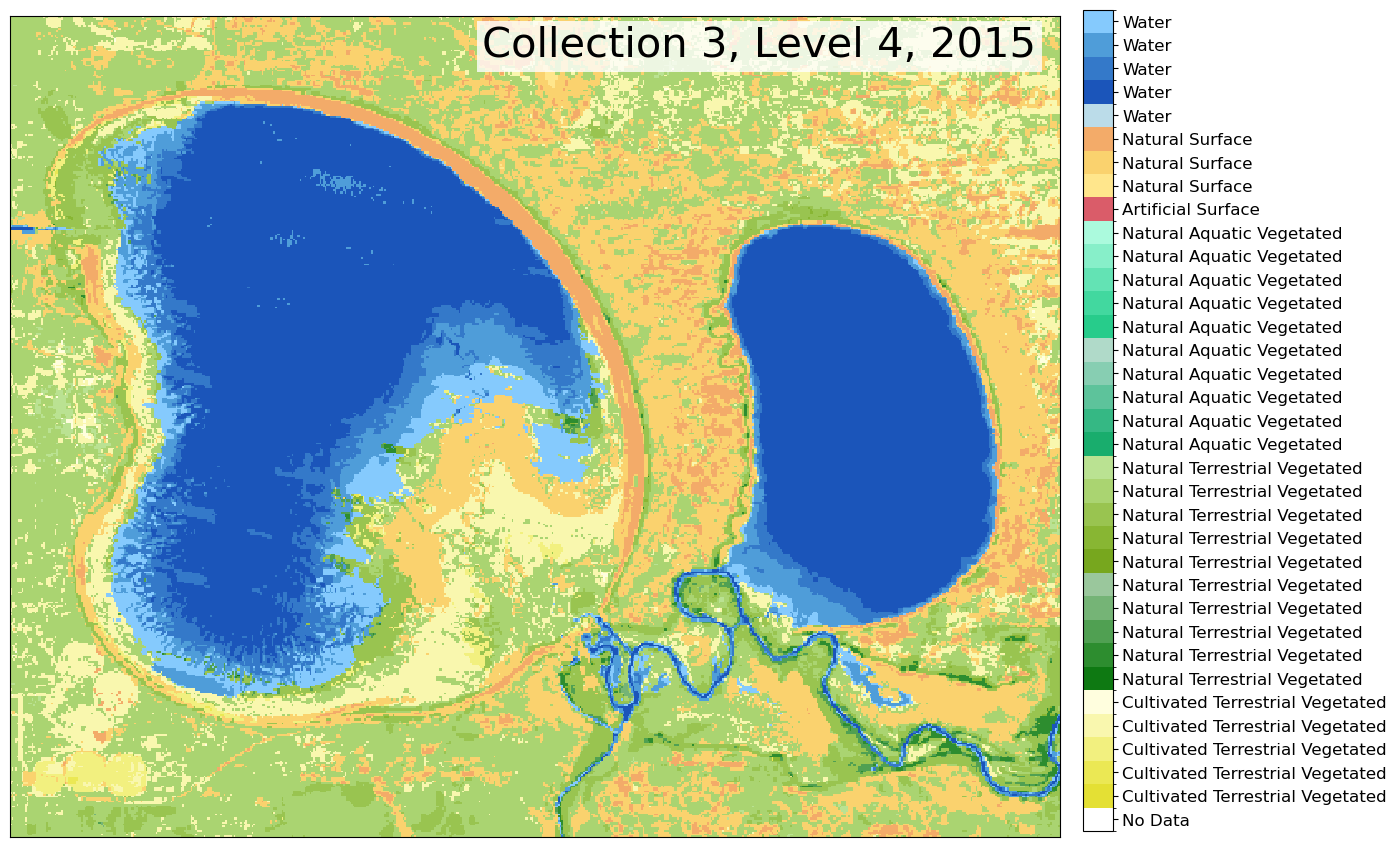

/tmp/ipykernel_153/1864024439.py:15: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(file_path)) # add file to list


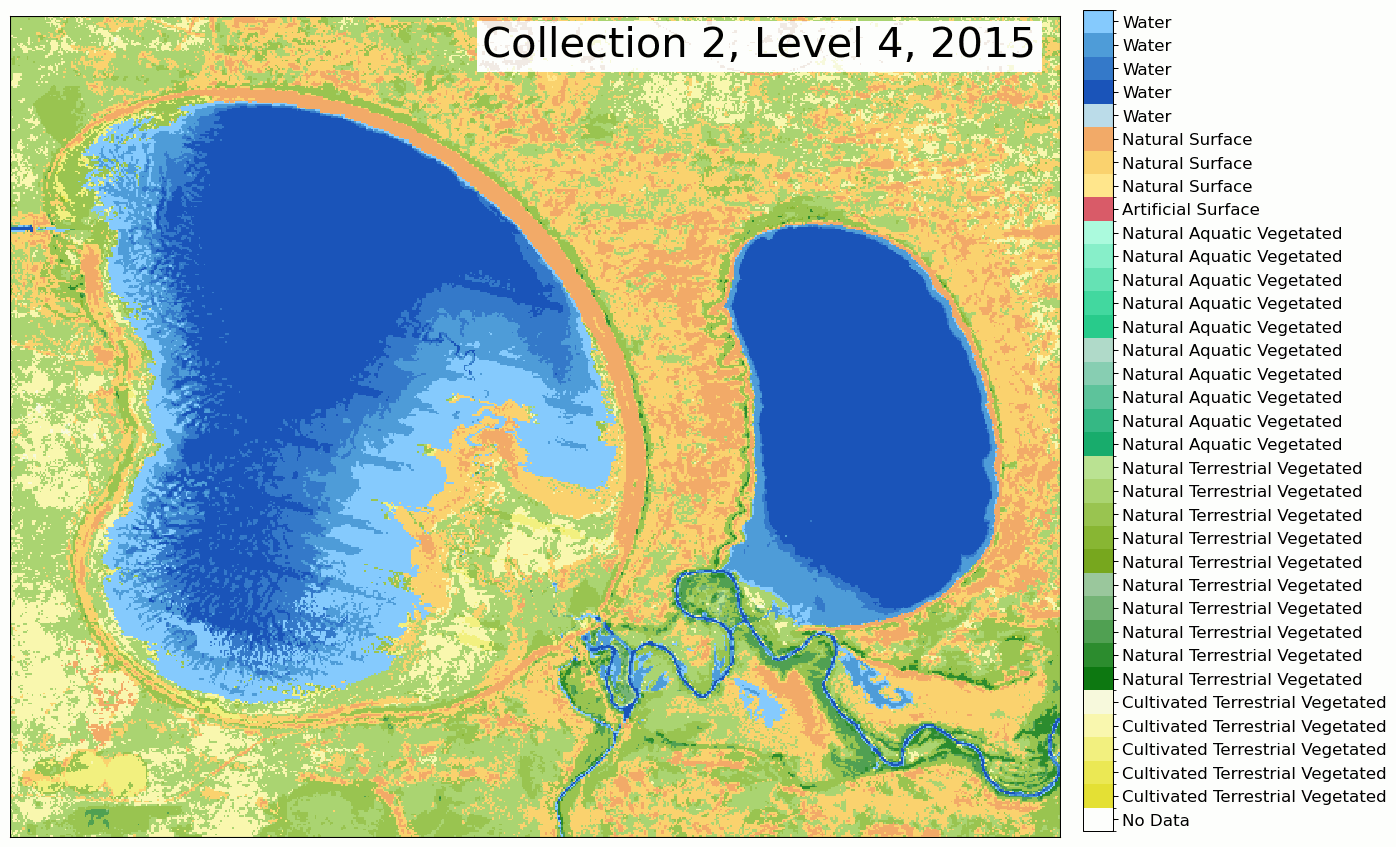

In [13]:
for band in ['level3','level4']:

    band_formatted = f'{band[:5].capitalize()} {band[-1]}'
    
    for ds, ds_name in zip([lc_2, lc_3], ['Collection 2', 'Collection 3']):
        save_fig(ds,band,time,comparison_out,ds_name)

    images = []
    
    for file_name in sorted(os.listdir(comparison_out)):
        
        if band_formatted in file_name and file_name.endswith('.png'):
            
            file_path = os.path.join(comparison_out, file_name)
            images.append(imageio.imread(file_path)) # add file to list

    gif_path = f'{comparison_out}/comparison {band} {time}.gif' #define gif file name
    
    imageio.mimsave(gif_path, images, fps=1, loop=0) # save gif
    display(Image(filename=gif_path)) # dsiplay gif

        